<font size="5">ChaosQKT with Psyduck: Quantum Chaos Simulation Tutorial:</font><br>
Tutorial for Quantum Chaos Simulations using the Psyduck Framework

This notebook demonstrates quantum chaos dynamics simulations using the **psyduck** library.
- `psyduck` module (core framework)
- `psyduck.plotting` subfolder (Wigner visualization)

# Section 1: Setup and import psyduck (and other stuff)



In [1]:
# %matplotlib inline
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import importlib

# Add the project root to Python path (2 levels up from examples/chaosqkt/)
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.insert(0, project_root)

# Force reload of psyduck modules
for module_name in list(sys.modules.keys()):
    if module_name.startswith('psyduck'):
        del sys.modules[module_name]

# Import psyduck library fresh
from psyduck import Spin
from psyduck.plotting import *
from psyduck.evolve import kicked_dynamics, otoc_trajectory
from psyduck.operations import global_rotation
from psyduck.hamiltonians import Hz_order

print("✓ Psyduck loaded successfully!")
print(f"QuTiP version: {qt.__version__}")


✓ Psyduck loaded successfully!
QuTiP version: 5.0.2


# Section 2: Create a Spin object using psyduck.

In [2]:
# Define spin quantum number
I = 7/2  # Spin-7/2 system (dimension 8)

# Create a Spin object using psyduck
nucleus = Spin(I=I)

print(f"✓ Created Spin system: I = {I},   Hilbert space dimension: {nucleus.dim}")

# Get spin operators
Ix, Iy, Iz = nucleus.get_spin_operators()
print(f"✓ Spin operators created (shape: {Ix.shape})")

✓ Created Spin system: I = 3.5,   Hilbert space dimension: 8
✓ Spin operators created (shape: (8, 8))


In [3]:
Ix

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.         1.32287566 0.         0.         0.         0.
  0.         0.        ]
 [1.32287566 0.         1.73205081 0.         0.         0.
  0.         0.        ]
 [0.         1.73205081 0.         1.93649167 0.         0.
  0.         0.        ]
 [0.         0.         1.93649167 0.         2.         0.
  0.         0.        ]
 [0.         0.         0.         2.         0.         1.93649167
  0.         0.        ]
 [0.         0.         0.         0.         1.93649167 0.
  1.73205081 0.        ]
 [0.         0.         0.         0.         0.         1.73205081
  0.         1.32287566]
 [0.         0.         0.         0.         0.         0.
  1.32287566 0.        ]]

# Section 3: Create Initial Spin-Coherent State

In [4]:
# Create a spin-coherent state at specific polar angles
theta = 0.0 * np.pi  # Polar angle (0 to π)
phi = 0.0 * np.pi   # Azimuthal angle (0 to 2π)

# Use the spin.py method to create the displaced coherent state
nucleus.make_displaced_coherent_state(theta=theta, phi=phi)
psi_initial = nucleus.state

print(f"✓ Created initial state at θ={theta:.3f}, φ={phi:.3f}")

✓ Created initial state at θ=0.000, φ=0.000


## 3.1a Visualize the Prepared State

Plot the Wigner (and Husimi Q) function of the prepared spin-coherent state using the projections available in `psyduck.plotting`:

- `wigner_plot_hammer` - Hammer equal-area projection
- `wigner_plot_3d` - 3D sphere
- `wigner_plot_polar` - polar (azimuthal-equidistant) projection
- `projection_plot_spin_wigner` - 3D sphere with three side projections
- `wigner_plot` - 3D + Hammer side-by-side

Each wrapper also accepts `prob_function='husimi'` to plot the Husimi Q distribution instead of the Wigner function.

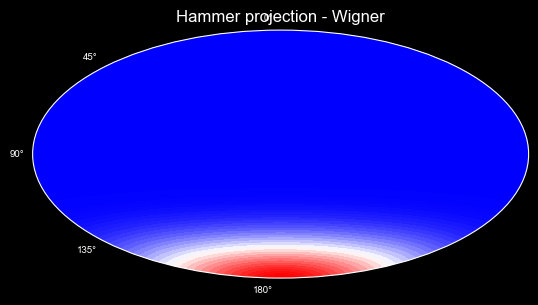

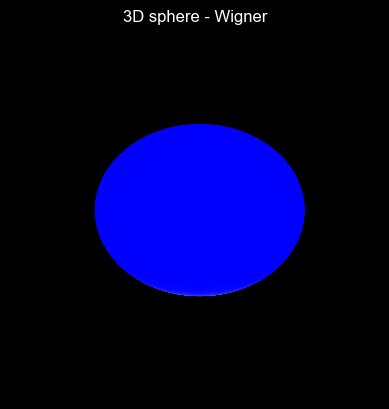

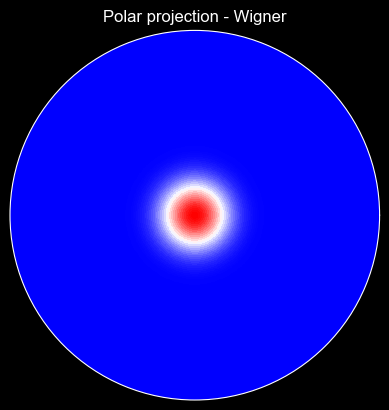

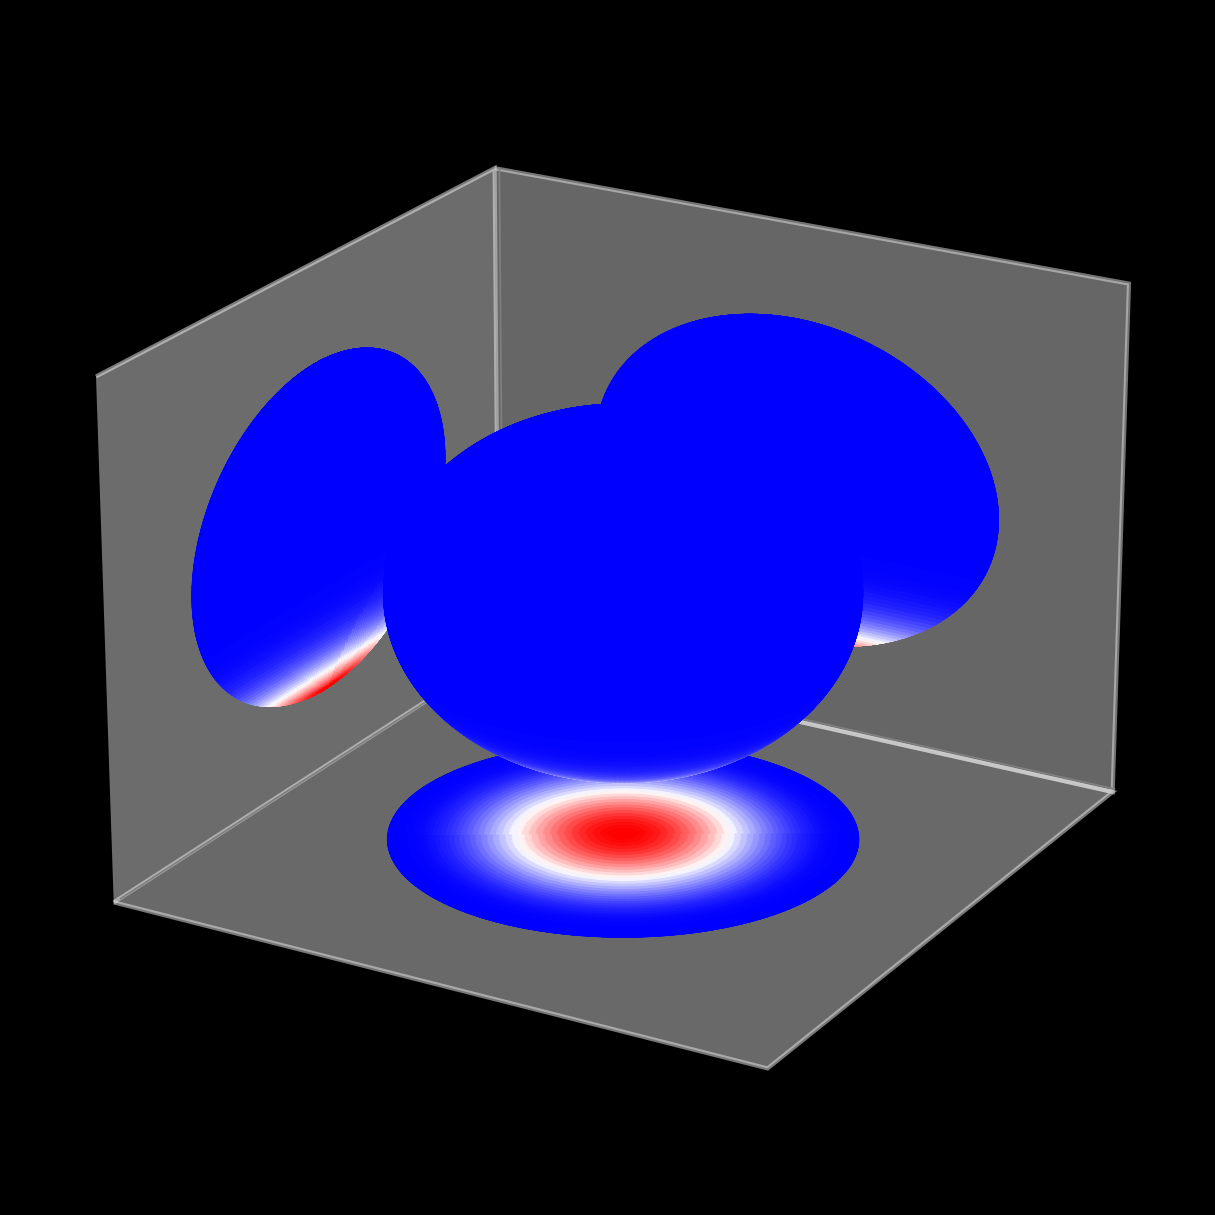

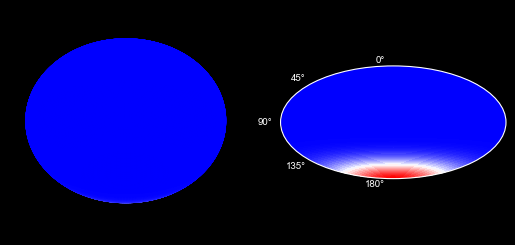

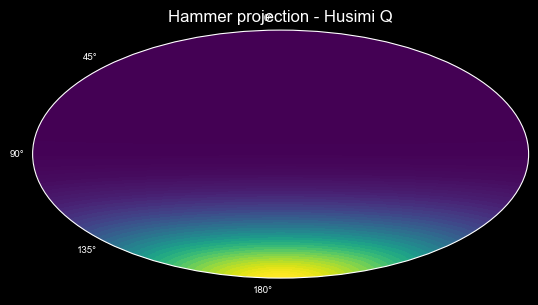

✓ Initial state visualized across multiple projections
  The sharp peak indicates a well-defined spin-coherent state


In [5]:
# 1. Hammer equal-area projection (Wigner)
fig, ax, _ = wigner_plot_hammer(psi_initial,n_theta=101,n_phi=201,cmap='bwr')
ax.set_title('Hammer projection - Wigner')
plt.show()

# 2. 3D sphere (Wigner)
fig, ax, _ = wigner_plot_3d(    psi_initial,n_theta=101,n_phi=201,cmap='bwr')
ax.set_title('3D sphere - Wigner')
plt.show()

# 3. Polar (azimuthal-equidistant) projection (Wigner)
fig, ax = wigner_plot_polar(psi_initial,n_theta=101,n_phi=201,cmap='bwr')
ax.set_title('Polar projection - Wigner')
plt.show()

# 4. 3D sphere with three side projections (Wigner)
fig, ax, _, _, _ = projection_plot_spin_wigner(psi_initial,n_theta=101,n_phi=201,cmap='bwr',figsize=(6, 5))
plt.show()

# 5. 3D + Hammer side-by-side via wigner_plot
wigner_plot(psi_initial)
plt.show()

# 6. Husimi Q distribution on a Hammer projection (compare with Wigner above)
fig, ax, _ = wigner_plot_hammer(psi_initial,n_theta=101,n_phi=201,cmap='viridis',prob_function='husimi')
ax.set_title('Hammer projection - Husimi Q')
plt.show()

print("✓ Initial state visualized across multiple projections")
print("  The sharp peak indicates a well-defined spin-coherent state")

### 3.1b Stereographic projection

Stereographic projection maps the sphere onto a plane by drawing a ray from one pole through every other point on the sphere to the equatorial plane.  It is **conformal** (angle-preserving) but not area-preserving: regions near the projection pole are stretched outward toward infinity.

With the projection point at the south pole (theta = pi), the planar radius is

$$r = 	an(	heta / 2), \qquad x = r \cos\phi, \qquad y = r \sin\phi.$$

So the north pole (theta = 0) lands at the origin and the south pole would map to infinity.  `wigner_plot_stereographic` masks points beyond a configurable `r_max` to keep the plot bounded, and `pole='north'` swaps the convention so the south pole sits at the centre instead.

C:\Users\z5459034\Documents\Gits\Psyduck\psyduck\plotting\wigner_plot.py:324: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(x, y, plot_data, cmap=cmap, vmin=vmin, vmax=vmax, **kwargs)


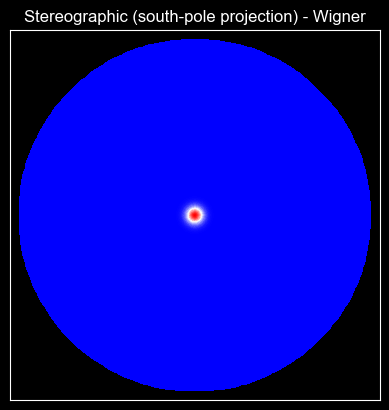

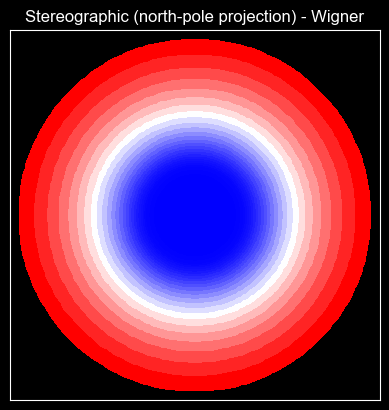

✓ Stereographic projection complete - compare angular sharpness with Hammer / polar above


In [6]:
# Stereographic projection (south-pole convention): north pole at centre
fig, ax, _ = wigner_plot_stereographic(
    psi_initial,
    n_theta=101,
    n_phi=201,
    cmap='bwr',
    pole='south'
)
ax.set_title('Stereographic (south-pole projection) - Wigner')
plt.show()

# Stereographic projection (north-pole convention): south pole at centre
fig, ax, _ = wigner_plot_stereographic(
    psi_initial,
    n_theta=101,
    n_phi=201,
    cmap='bwr',
    pole='north'
)
ax.set_title('Stereographic (north-pole projection) - Wigner')
plt.show()

print("✓ Stereographic projection complete - compare angular sharpness with Hammer / polar above")

## 3.2 Expectation Values and Linear Entropy of the nucleus

In [7]:
# Calculate expectation values using Spin.expectation() method
exp_Ix = nucleus.expectation(Ix)
exp_Iy = nucleus.expectation(Iy)
exp_Iz = nucleus.expectation(Iz)
print(f"\nExpectation values using nucleus.expectation():")
print(f"  <Jx> = {exp_Ix:.4f}")
print(f"  <Jy> = {exp_Iy:.4f}")
print(f"  <Jz> = {exp_Iz:.4f}")

# Calculate linear entropy using nucleus.linear_entropy() method
entropy = nucleus.linear_entropy()
print(f"\nLinear entropy (using nucleus.linear_entropy):\n {entropy:.6f}")


Expectation values using nucleus.expectation():
  <Jx> = 0.0000
  <Jy> = 0.0000
  <Jz> = 3.5000

Linear entropy (using nucleus.linear_entropy):
 0.000000


# Section 4: Run Kicked Dynamics Simulation

Simulate the quantum kicked top with nonlinear pulses, then visualize the evolution with an interactive slider showing Wigner functions in Hammer projection after each kick. The Hamiltonian of the kicked top has the form,
$$
H(t) = -\frac{\pi}{2\tau} I_y + \frac{\kappa}{2j} I_z^2
$$
equation (2) from
Neill, C. et al. "Ergodic dynamics and thermalization in an isolated quantum system." Nature Phys 12, 1037–1041 (2016).

Note here, in `kicked_dynamics(psi_initial, tau, kappa, I, N, order, pulse_type)`: <br> 
the `Y-rotaion is $-I_{y}$` because this is the how the rotation is implemented by the OPX+ in experiment. <br>

The `order` argument sets the power of the nonlinear kick operator, `U_pulse = exp[-i * kappa * I_z**order / (order * I**(order - 1))]`.
The `order` parameter controls the nonlinearity:
- **Order 2** (quadratic): $I_z^2$ -> weaker, smoother
- **Order 3** (cubic): $I_z^3$ -> stronger, more chaotic
- **Higher orders**: More complex classical dynamics


In [8]:
# Simulation parameters
tau = 1.0           # Free evolution time between kicks, tau=1 means a pi/2 y-rotation between kicks
kappa = 3.5 * np.pi # Kick strength (nonlinearity parameter), with j=7/2 this results in a pi/2 Iz^2 operation that creates a cat state for checking.
N_kicks = 20        # Number of kicks
order = 2           # Nonlinear kick order

print("Running kicked dynamics simulation...")
print(f"Parameters: tau={tau}, kappa={kappa}, N={N_kicks}, order={order}")
# Use kicked_dynamics from psyduck.evolve
psi_list, overlap_list, entropy_list, exp_list = kicked_dynamics(
    psi_initial, tau, kappa, I, N=N_kicks, order=order, pulse_type='pulse'
)
print(f"✓ Simulation completed!")
print(f"  Generated {len(psi_list)} states")

Running kicked dynamics simulation...
Parameters: tau=1.0, kappa=10.995574287564276, N=20, order=2
✓ Simulation completed!
  Generated 21 states


## 4.1 Interactive Wigner Function Visualization with Slider
Use the slider below to explore the Wigner function after each kick. The Hammer projection shows the phase space evolution throughout the simulation.

In [9]:
from psyduck.plotting.wigner_plot import plot_wigner_evolution_frame
from ipywidgets import interact, IntSlider, fixed
# %matplotlib inline

# Create interactive slider widget
print("\n" + "="*70)
print("Interactive Wigner Function Visualization")
print("="*70)
print(f"Slide to browse through all {len(psi_list)} states")
print(f"Observe phase space evolution from kick 0 to {N_kicks}")
print("="*70 + "\n")

interact(
    plot_wigner_evolution_frame,
    kick_number=IntSlider(
        min=0,
        max=N_kicks,
        step=1,
        value=0,
        description="Kick:",
        continuous_update=True,
        layout={"width": "500px"}
    ),
    n_theta=IntSlider(
        min=1,
        max=303,
        step=1,
        value=101,
        description="n_theta:",
        continuous_update=False,
        layout={"width": "500px"}
    ),
    n_phi=IntSlider(
        min=1,
        max=603,
        step=1,
        value=201,
        description="n_phi:",
        continuous_update=False,
        layout={"width": "500px"}
    ),
    psi_list=fixed(psi_list),
    entropy_list=fixed(entropy_list),
    overlap_list=fixed(overlap_list)
)


Interactive Wigner Function Visualization
Slide to browse through all 21 states
Observe phase space evolution from kick 0 to 20



interactive(children=(IntSlider(value=0, description='Kick:', layout=Layout(width='500px'), max=20), IntSlider…

<function psyduck.plotting.wigner_plot.plot_wigner_evolution_frame(kick_number, psi_list, entropy_list, overlap_list, n_theta=101, n_phi=201, cmap='bwr')>

## Section 4.2: Plot Evolution Metrics

Visualize the system dynamics across all kicks from the Section 4 simulation.

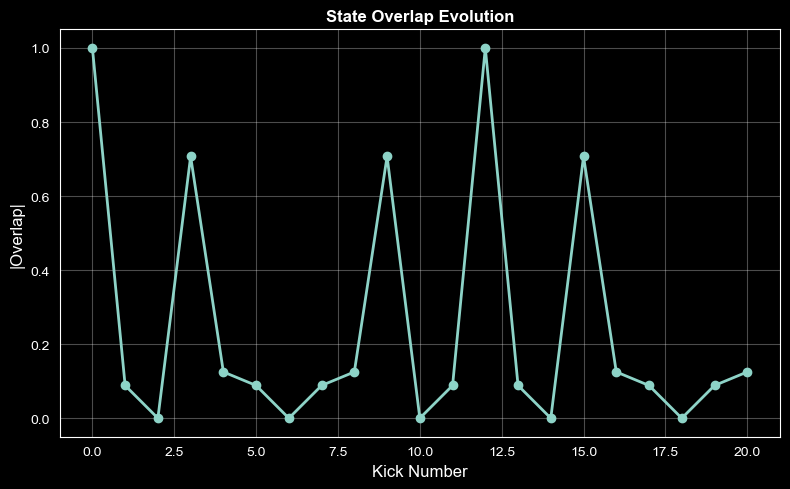

In [10]:
# Plot 1: Overlap evolution
fig_overlap, ax_overlap = plt.subplots(figsize=(8, 5))
ax_overlap.plot(range(len(overlap_list)), abs(np.array(overlap_list)), 'o-', 
                linewidth=2, markersize=6, color='C0')
ax_overlap.set_xlabel('Kick Number', fontsize=12)
ax_overlap.set_ylabel('|Overlap|', fontsize=12)
ax_overlap.set_title('State Overlap Evolution', fontsize=12, fontweight='bold')
ax_overlap.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

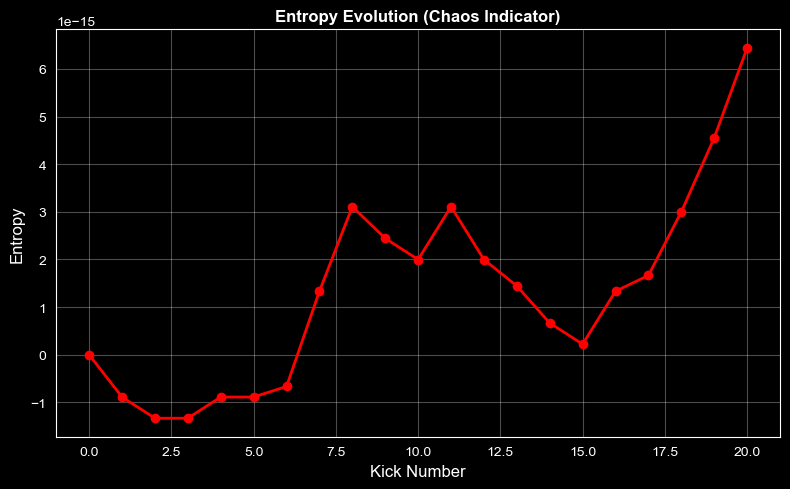

In [11]:
# Plot 2: Entropy evolution
fig_entropy, ax_entropy = plt.subplots(figsize=(8, 5))
ax_entropy.plot(range(len(entropy_list)), entropy_list, 'o-', 
                color='red', linewidth=2, markersize=6)
ax_entropy.set_xlabel('Kick Number', fontsize=12)
ax_entropy.set_ylabel('Entropy', fontsize=12)
ax_entropy.set_title('Entropy Evolution (Chaos Indicator)', fontsize=12, fontweight='bold')
ax_entropy.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

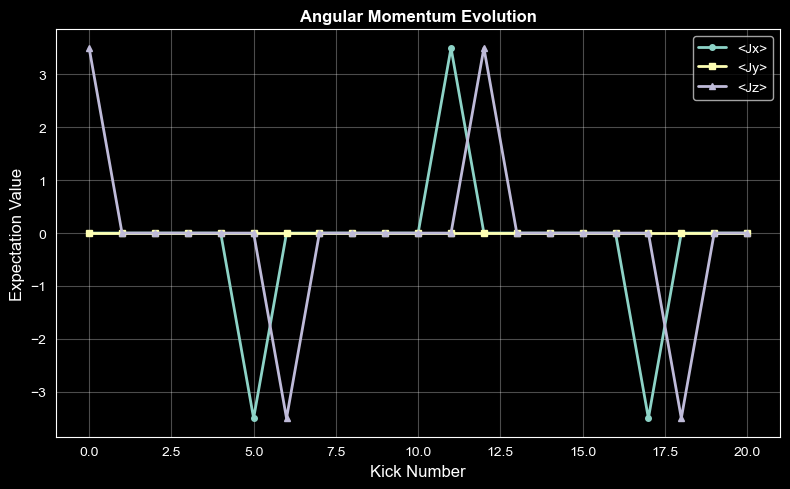

In [12]:
# Plot 3: Expectation values evolution
exp_array = np.array(exp_list)
kicks = np.arange(len(exp_list))
fig_exp, ax_exp = plt.subplots(figsize=(8, 5))
ax_exp.plot(kicks, exp_array[:, 0], 'o-', label='<Jx>', linewidth=2, markersize=4)
ax_exp.plot(kicks, exp_array[:, 1], 's-', label='<Jy>', linewidth=2, markersize=4)
ax_exp.plot(kicks, exp_array[:, 2], '^-', label='<Jz>', linewidth=2, markersize=4)
ax_exp.set_xlabel('Kick Number', fontsize=12)
ax_exp.set_ylabel('Expectation Value', fontsize=12)
ax_exp.set_title('Angular Momentum Evolution', fontsize=12, fontweight='bold')
ax_exp.legend(fontsize=10)
ax_exp.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Section 5: Kicked Dynamics vs Different Spin Numbers
Run kicked dynamics with tunable spin number I (other parameters fixed), then compare the state overlap evolution across different spin systems and inspect their FFT spectra for dynamical-tunneling signatures.

## Section 5.1 - Cell 1: Set the tunable parameters then run kicked_dynamics for each spin

In [13]:
# ===== TUNABLE PARAMETERS =====
spin_numbers = [3.5, 8.5, 40.5, 100.5]   # List of spin numbers I to compare
tau          = 1.0                       # Free evolution time between kicks
kappa        = 3.5 * np.pi               # Kick strength (nonlinearity parameter)
N_kicks      = 500                        # Number of kicks
order        = 2                         # Nonlinear kick order
theta0, phi0 = 0.0, 0.0                  # Initial coherent-state angles
# ==============================

print("=" * 70)
print("Section 5: Comparing kicked-top evolution across spin numbers")
print("=" * 70)
print(f"Fixed: tau={tau}, kappa={kappa:.4f}, N_kicks={N_kicks}, order={order}")
print(f"Initial coherent state: theta={theta0}, phi={phi0}")
print(f"Varying spin numbers: {spin_numbers}")

overlap_data = {}
entropy_data = {}

for spin_I in spin_numbers:
    nucleus_compare = Spin(I=spin_I)
    nucleus_compare.make_displaced_coherent_state(theta=theta0, phi=phi0)
    psi_initial_compare = nucleus_compare.state

    psi_list, overlap_list, entropy_list, exp_list = kicked_dynamics(
        psi_initial_compare, tau, kappa, spin_I,
        N=N_kicks, order=order, pulse_type='pulse',
    )

    overlap_data[spin_I] = overlap_list
    entropy_data[spin_I] = entropy_list


Section 5: Comparing kicked-top evolution across spin numbers
Fixed: tau=1.0, kappa=10.9956, N_kicks=500, order=2
Initial coherent state: theta=0.0, phi=0.0
Varying spin numbers: [3.5, 8.5, 40.5, 100.5]


##  Section 5.2 Overlap evolution comparison across spin numbers

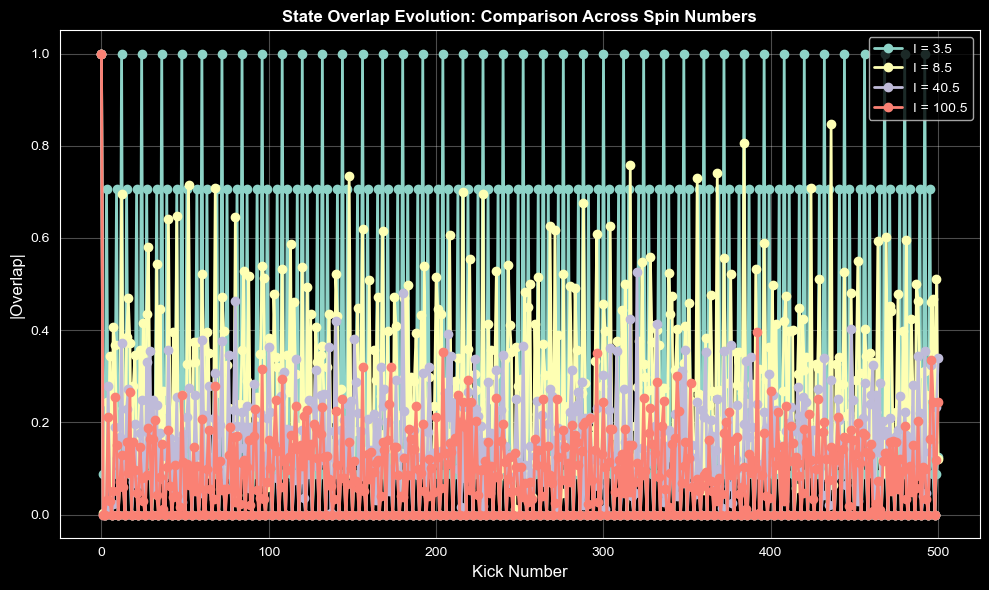

In [14]:
# Section 5 - Cell 2: Overlap evolution comparison across spin numbers
fig_overlap_compare, ax_overlap_compare = plt.subplots(figsize=(10, 6))

for spin_I in spin_numbers:
    ax_overlap_compare.plot(
        range(len(overlap_data[spin_I])),
        np.abs(np.asarray(overlap_data[spin_I])),
        'o-', linewidth=2, markersize=6, label=f'I = {spin_I}',
    )

ax_overlap_compare.set_xlabel('Kick Number', fontsize=12)
ax_overlap_compare.set_ylabel('|Overlap|', fontsize=12)
ax_overlap_compare.set_title(
    'State Overlap Evolution: Comparison Across Spin Numbers',
    fontsize=12, fontweight='bold',
)
ax_overlap_compare.legend(fontsize=10)
ax_overlap_compare.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Section 5.3 Per-spin |Overlap| vs Kick (left) and its FFT spectrum (right)

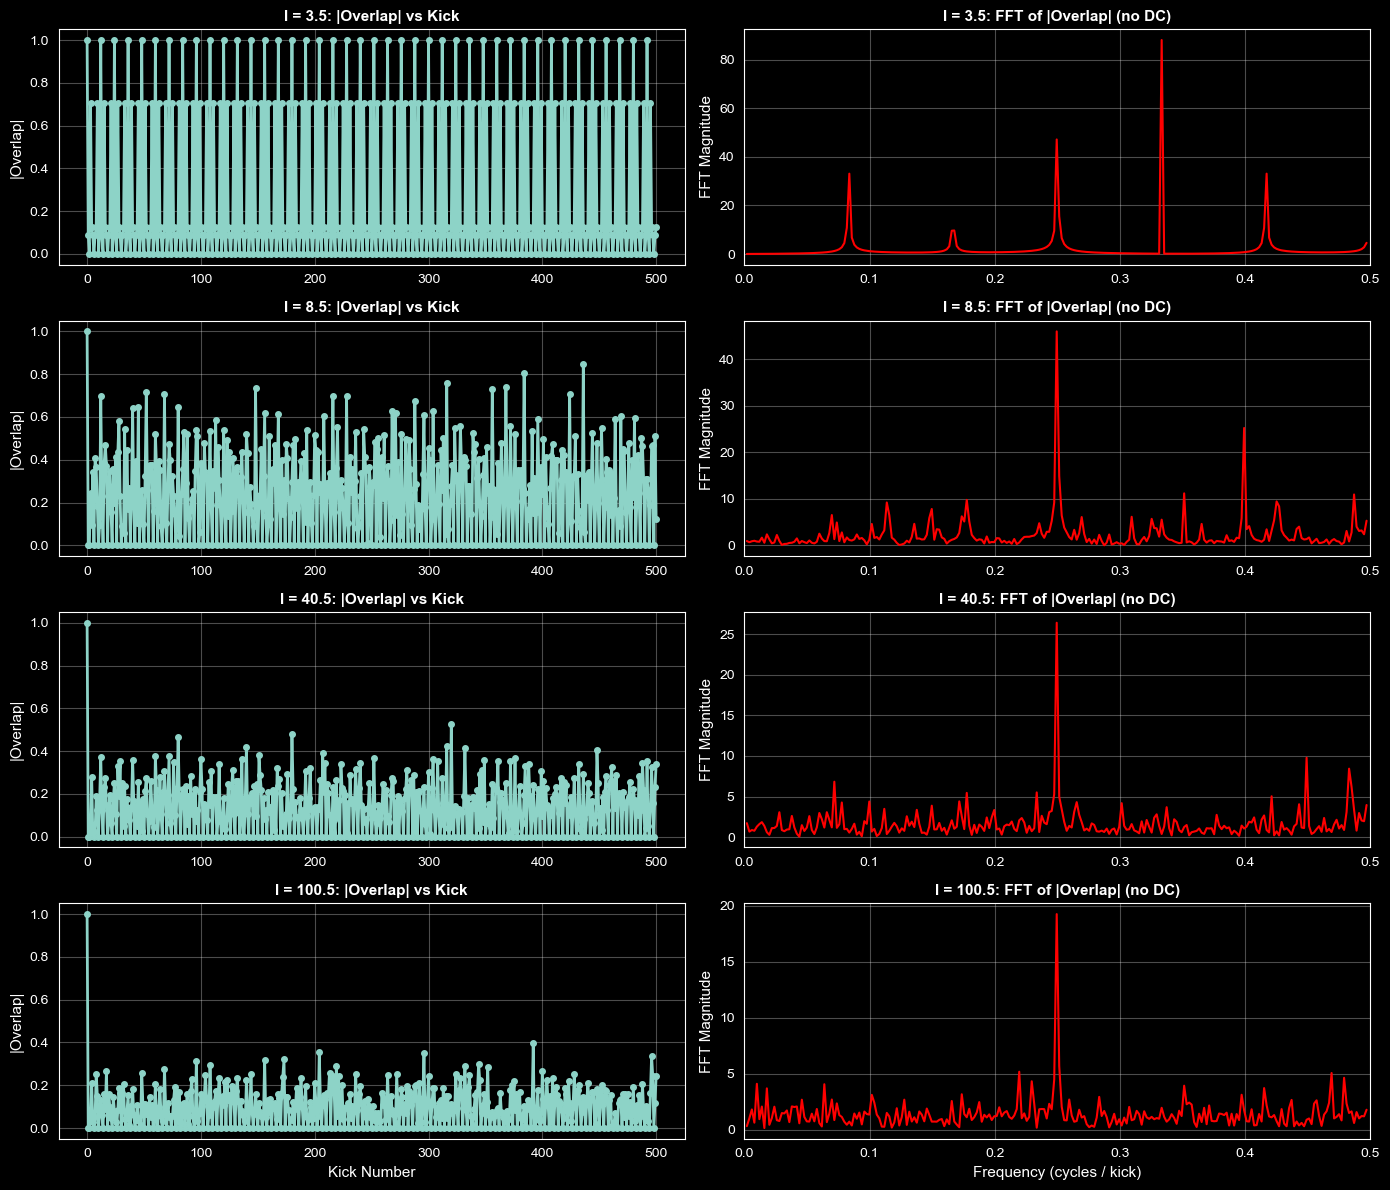

In [15]:
# Section 5 - Cell 3: 
n_spins = len(spin_numbers)
fft_data = {}

for spin_I in spin_numbers:
    overlap_mag = np.abs(np.asarray(overlap_data[spin_I]))
    fft_vals  = np.fft.fft(overlap_mag)
    fft_freqs = np.fft.fftfreq(len(overlap_mag))
    half = len(overlap_mag) // 2
    # Positive-frequency half, DC bin dropped
    fft_data[spin_I] = (fft_freqs[1:half], np.abs(fft_vals[1:half]))

fig, axes = plt.subplots(n_spins, 2, figsize=(14, 3 * n_spins), squeeze=False)

for idx, spin_I in enumerate(spin_numbers):
    overlap_mag = np.abs(np.asarray(overlap_data[spin_I]))
    fft_freqs, fft_mag = fft_data[spin_I]

    axes[idx, 0].plot(range(len(overlap_mag)), overlap_mag, 'o-',
                       linewidth=2, markersize=4, color='C0')
    axes[idx, 0].set_ylabel('|Overlap|', fontsize=11)
    axes[idx, 0].set_title(f'I = {spin_I}: |Overlap| vs Kick',
                            fontsize=11, fontweight='bold')
    axes[idx, 0].grid(True, alpha=0.3)

    axes[idx, 1].plot(fft_freqs, fft_mag, linewidth=1.5, color='red')
    axes[idx, 1].set_xlim(0, 0.5)
    axes[idx, 1].set_ylabel('FFT Magnitude', fontsize=11)
    axes[idx, 1].set_title(f'I = {spin_I}: FFT of |Overlap| (no DC)',
                            fontsize=11, fontweight='bold')
    axes[idx, 1].grid(True, alpha=0.3)

axes[-1, 0].set_xlabel('Kick Number', fontsize=11)
axes[-1, 1].set_xlabel('Frequency (cycles / kick)', fontsize=11)

plt.tight_layout()
plt.show()


# Section 6: Trotterized vs Continuous Kicked-Top Evolution

This section uses the `psyduck` workflow end-to-end:
- create the system with `nucleus = Spin(I=...)`
- build the higher-order kick with `psyduck.hamiltonians.Hz_order(...)`
- run the Trotterized dynamics by reusing `psyduck.evolve.kicked_dynamics()` with rescaled `tau` and `kappa` (see Section 6.1 for the parameter mapping)
- compare the Trotterized dynamics against `Spin.evolve()` under the full continuous Hamiltonian

We will:
1. set the parameters for both the Trotterized and continuous evolutions
2. run both evolutions and compare their final states with side-by-side Wigner plots
3. compare the population trajectories of the Trotterized and continuous evolutions
4. compare the state overlap (fidelity) and Iz expectation-value error as `delta_tau -> 0`
5. sweep both `T_total` and `n_trotter` to see how the approximation error scales

## 6.1 Set parameters

Parameters are grouped into three blocks: those used by **both** evolutions, those used **only by the Trotterized** evolution, and those used **only by the continuous** evolution.

In [16]:
# Section 6.1: Set parameters
#
# Three blocks below: shared, Trotter-only, continuous-only.

# ==================== (a) Shared parameters ====================
# These define the physical system and the kicked-top Hamiltonian
#       H = -omega_y * Iy + Hz_order(kappa, order, I)
# and are reused by both the Trotterized and the continuous evolutions.
I       = 3.5                   # Spin quantum number
theta0  = np.pi / 2             # Initial coherent-state polar angle
phi0    = 0.0                   # Initial coherent-state azimuthal angle
order   = 2                     # Nonlinearity order of the Iz kick
kappa   = 3.5 * np.pi           # Iz kick strength (entering Hz_order)
omega_y = np.pi / 2             # Y-drive strength (Hy = -omega_y * Iy)
T_total = 2.0                   # Total evolution time

# Build the initial state and the spin operators on the chosen Hilbert space.
nucleus = Spin(I=I)
nucleus.make_displaced_coherent_state(theta=theta0, phi=phi0)
psi0    = nucleus.state.copy()
Ix, Iy, Iz = nucleus.get_spin_operators()


# ==================== (b) Trotter-only parameters ====================
# n_trotter sets the number of discrete steps; delta_tau is the per-step duration.
# kicked_dynamics(psi, tau, kappa, I, N, order, pulse_type='pulse') applies
#       U0 = exp(-i * (pi/2) * (-Iy) * tau)
#       Upulse = exp(-i * Hz_order(kappa, order, I))
# so we rescale tau and kappa per step:
#       tau_kd   absorbs omega_y into the baked-in pi/2 Y-drive
#       kappa_kd turns the instantaneous kick into an effective delta_tau * Hz step
n_trotter = 10
delta_tau = T_total / n_trotter
tau_kd    = 2 * omega_y * delta_tau / np.pi
kappa_kd  = kappa * delta_tau


# ==================== (c) Continuous-only parameters ====================
# continuous_dt is the fine sampling step used by Spin.evolve.
# H_total is the continuous-time generator that Spin.evolve integrates.
continuous_dt        = 1e-3
continuous_num_steps = int(T_total / continuous_dt) + 1
continuous_times     = np.linspace(0, T_total, continuous_num_steps)

Hz      = Hz_order(kappa, order, I)
Hy      = -omega_y * Iy
H_total = Hy + Hz
H_total

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[19.242255  +0.j          0.        +2.07796822j  0.        +0.j
   0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        -2.07796822j  9.81747704+0.j          0.        +2.72069905j
   0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        -2.72069905j  3.53429174+0.j
   0.        +3.04183401j  0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        -3.04183401j
   0.39269908+0.j          0.        +3.14159265j  0.        +0.j
   0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        -3.14159265j  0.39269908+0.j          0.        +3.04183401j
   0.        +0.j

## 6.2 Run both evolutions and compare final states

Run the Trotterized dynamics via `kicked_dynamics` and the continuous reference via `Spin.evolve(H_total, ...)`, then place their final-state Wigner functions (Hammer projection) side-by-side.

Trotterized: n_trotter = 10, delta_tau = 0.200000
Continuous : n_steps   = 2001
Fidelity between Trotterized and continuous final states = 0.952950


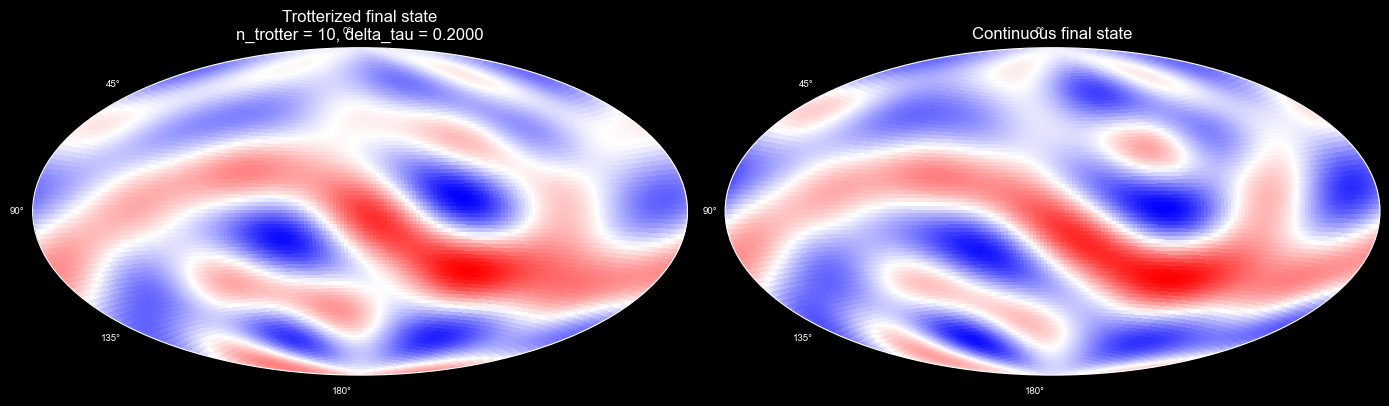

In [17]:
# Section 6.2: Run the Trotterized and continuous evolutions, then compare final states.

# ==================== Trotterized evolution ====================
psi_trotter_trajectory, _, _, _ = kicked_dynamics(
    psi0,
    tau=tau_kd,
    kappa=kappa_kd,
    I=I,
    N=n_trotter,
    order=order,
    pulse_type='pulse',
)
trotter_populations = np.array(
    [np.abs(s.full().ravel()) ** 2 for s in psi_trotter_trajectory]
)
psi_trotter_final = psi_trotter_trajectory[-1]
time_grid         = np.linspace(0, T_total, n_trotter + 1)

# ==================== Continuous evolution ====================
continuous_nucleus = Spin(I=I)
continuous_nucleus.state = psi0.copy()
continuous_series        = continuous_nucleus.evolve(H_total, continuous_times)
psi_continuous_trajectory = continuous_series.states
continuous_populations    = continuous_series.populations()
psi_continuous_final      = psi_continuous_trajectory[-1]
continuous_time_grid      = continuous_times

# ==================== Final-state comparison ====================
comparison_fidelity = qt.fidelity(psi_trotter_final, psi_continuous_final)
print(f"Trotterized: n_trotter = {n_trotter}, delta_tau = {delta_tau:.6f}")
print(f"Continuous : n_steps   = {continuous_num_steps}")
print(f"Fidelity between Trotterized and continuous final states = {comparison_fidelity:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw={'projection': 'hammer'})

wigner_plot_hammer(
    psi_trotter_final, fig=fig, ax=axes[0],
    n_theta=101, n_phi=201, cmap='bwr',
)
axes[0].set_title(
    f'Trotterized final state\nn_trotter = {n_trotter}, delta_tau = {delta_tau:.4f}'
)

wigner_plot_hammer(
    psi_continuous_final, fig=fig, ax=axes[1],
    n_theta=101, n_phi=201, cmap='bwr',
)
axes[1].set_title('Continuous final state')

plt.tight_layout()
plt.show()


## 6.3 Compare population trajectories

Compare the time evolution of the populations for the same basis states in the Trotterized and continuous evolutions. Each trajectory is plotted on its own time grid.

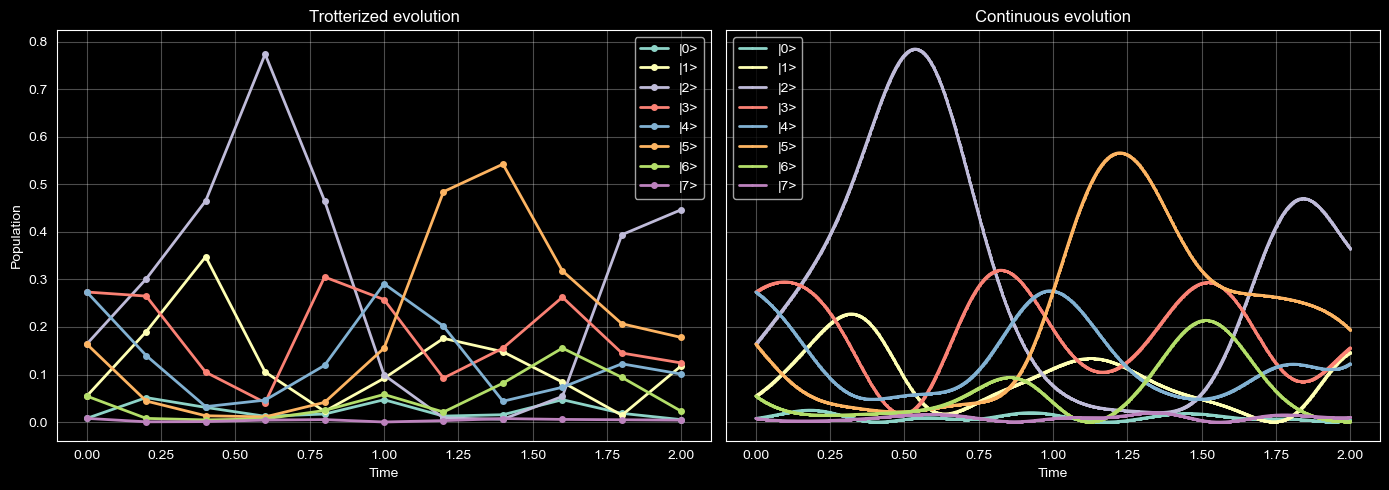

In [18]:
# Section 6.3: Population evolution of Trotterized vs continuous dynamics
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx in np.arange(8):
    axes[0].plot(
        time_grid, trotter_populations[:, idx],
        'o-', linewidth=2, markersize=4, label=f'|{idx}>',
    )
    axes[1].plot(
        continuous_time_grid, continuous_populations[:, idx],
        'o-', linewidth=2, markersize=1, label=f'|{idx}>',
    )

axes[0].set_title('Trotterized evolution')
axes[1].set_title('Continuous evolution')

for ax in axes:
    ax.set_xlabel('Time')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Population')
plt.tight_layout()
plt.show()


## 6.4 Compare state overlap (fidelity) and Iz expectation-value error

Repeat the Section 6.2 comparison for several Trotter step counts. As `delta_tau = T_total / n_trotter` shrinks, the Trotterized result should approach the continuous one in both fidelity and the Iz expectation value.

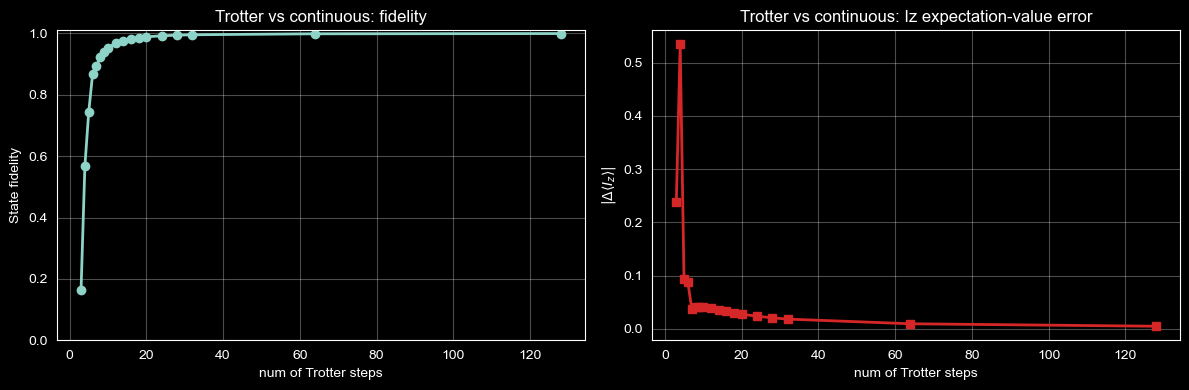

n_steps    delta_tau    fidelity    delta_Iz
      3     0.666667    0.164362       2.386454e-01
      4     0.500000    0.567784       5.341087e-01
      5     0.400000    0.743639       9.329048e-02
      6     0.333333    0.866613       8.754614e-02
      7     0.285714    0.894229       3.800604e-02
      8     0.250000    0.922126       4.086847e-02
      9     0.222222    0.940575       4.130756e-02
     10     0.200000    0.952950       4.096992e-02
     12     0.166667    0.968255       3.868087e-02
     14     0.142857    0.977077       3.563171e-02
     16     0.125000    0.982649       3.261402e-02
     18     0.111111    0.986400       2.987583e-02
     20     0.100000    0.989049       2.746394e-02
     24     0.083333    0.992456       2.352109e-02
     28     0.071429    0.994485       2.049727e-02
     32     0.062500    0.995793       1.813192e-02
     64     0.031250    0.998959       9.335767e-03
    128     0.015625    0.999741       4.715160e-03


In [19]:
# Section 6.4: Convergence in fidelity and |Delta<Iz>| as delta_tau -> 0

trotter_step_list = np.array([3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 18, 20, 24, 28, 32, 64, 128])
n_steps_array   = np.zeros(len(trotter_step_list), dtype=int)
delta_tau_array = np.zeros(len(trotter_step_list), dtype=float)
fidelity_array  = np.zeros(len(trotter_step_list), dtype=float)
delta_Iz_array  = np.zeros(len(trotter_step_list), dtype=float)

# Reference: <Iz> from the continuous final state
Iz_continuous = qt.expect(Iz, psi_continuous_final)

for idx, n_steps in enumerate(trotter_step_list):
    delta_tau_local = T_total / n_steps
    tau_local       = 2 * omega_y * delta_tau_local / np.pi
    kappa_local     = kappa * delta_tau_local

    psi_traj_local, _, _, _ = kicked_dynamics(
        psi0, tau=tau_local, kappa=kappa_local, I=I,
        N=int(n_steps), order=order, pulse_type='pulse',
    )
    psi_local_final = psi_traj_local[-1]

    fidelity_local = qt.fidelity(psi_local_final, psi_continuous_final)
    Iz_local       = qt.expect(Iz, psi_local_final)
    delta_Iz_local = np.abs(Iz_local - Iz_continuous)

    n_steps_array[idx]   = n_steps
    delta_tau_array[idx] = delta_tau_local
    fidelity_array[idx]  = fidelity_local
    delta_Iz_array[idx]  = delta_Iz_local

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(n_steps_array, fidelity_array, 'o-', linewidth=2)
axes[0].set_xlabel('num of Trotter steps')
axes[0].set_ylabel('State fidelity')
axes[0].set_title('Trotter vs continuous: fidelity')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.01)

axes[1].plot(n_steps_array, delta_Iz_array, 's-', linewidth=2, color='tab:red')
axes[1].set_xlabel('num of Trotter steps')
axes[1].set_ylabel(r'$|\Delta\langle I_z\rangle|$')
axes[1].set_title('Trotter vs continuous: Iz expectation-value error')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("n_steps    delta_tau    fidelity    delta_Iz")
for idx in range(len(trotter_step_list)):
    print(
        f"{n_steps_array[idx]:>7d}  {delta_tau_array[idx]:>11.6f}  "
        f"{fidelity_array[idx]:>10.6f}  {delta_Iz_array[idx]:>17.6e}"
    )


## 6.5 Sweep `T_total` and `n_trotter`

Sweep both the total evolution time and the Trotter step count to map how the approximation error scales with duration and discretization. Each curve in the plot corresponds to one `T_total`.

In [20]:
# Section 6.5: Sweep T_total and n_trotter, then plot fidelity and Iz error.

T_total_list   = np.array([0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5, 15.5, 20.5], dtype=float)
n_trotter_list = np.array([3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16, 20, 24, 28, 32], dtype=int)

n_T_values = len(T_total_list)
n_n_values = len(n_trotter_list)

fidelity_matrix = np.zeros((n_T_values, n_n_values), dtype=float)
delta_Iz_matrix = np.zeros((n_T_values, n_n_values), dtype=float)

print("=" * 80)
print("Section 6.5: Comparing convergence across T_total and n_trotter")
print("=" * 80)
print(f"T_total values  : {T_total_list}")
print(f"n_trotter values: {n_trotter_list}\n")

for t_idx, T_total_val in enumerate(T_total_list):
    # print(f"\nT_total = {T_total_val:.2f}:")
    for n_idx, n_trotter_val in enumerate(n_trotter_list):
        delta_tau_sweep = T_total_val / n_trotter_val
        tau_sweep       = 2 * omega_y * delta_tau_sweep / np.pi
        kappa_sweep     = kappa * delta_tau_sweep

        # Trotterized evolution via kicked_dynamics
        psi_trotter_sweep_list, _, _, _ = kicked_dynamics(
            psi0, tau=tau_sweep, kappa=kappa_sweep, I=I,
            N=int(n_trotter_val), order=order, pulse_type='pulse',
        )
        psi_trotter_sweep = psi_trotter_sweep_list[-1]

        # Continuous evolution via Spin.evolve on the same endpoint
        sweep_nucleus = Spin(I=I)
        sweep_nucleus.state = psi0.copy()
        continuous_series_sweep = sweep_nucleus.evolve(
            H_total, np.linspace(0, T_total_val, int(n_trotter_val) + 1)
        )
        psi_continuous_sweep = continuous_series_sweep.states[-1]

        fidelity_sweep        = qt.fidelity(psi_trotter_sweep, psi_continuous_sweep)
        Iz_continuous_sweep   = qt.expect(Iz, psi_continuous_sweep)
        Iz_trotter_sweep      = qt.expect(Iz, psi_trotter_sweep)
        delta_Iz_sweep        = np.abs(Iz_trotter_sweep - Iz_continuous_sweep)

        fidelity_matrix[t_idx, n_idx] = fidelity_sweep
        delta_Iz_matrix[t_idx, n_idx] = delta_Iz_sweep

        # print(
        #     f"  n_trotter = {n_trotter_val:2d}: "
        #     f"fidelity = {fidelity_sweep:.6f}, "
        #     f"Delta<Iz> = {delta_Iz_sweep:.6e}"
        # )

print("=" * 80)




Section 6.5: Comparing convergence across T_total and n_trotter
T_total values  : [ 0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.5  6.5  7.5  8.5  9.5
 10.5 15.5 20.5]
n_trotter values: [ 3  4  5  6  7  8  9 10 12 14 16 20 24 28 32]



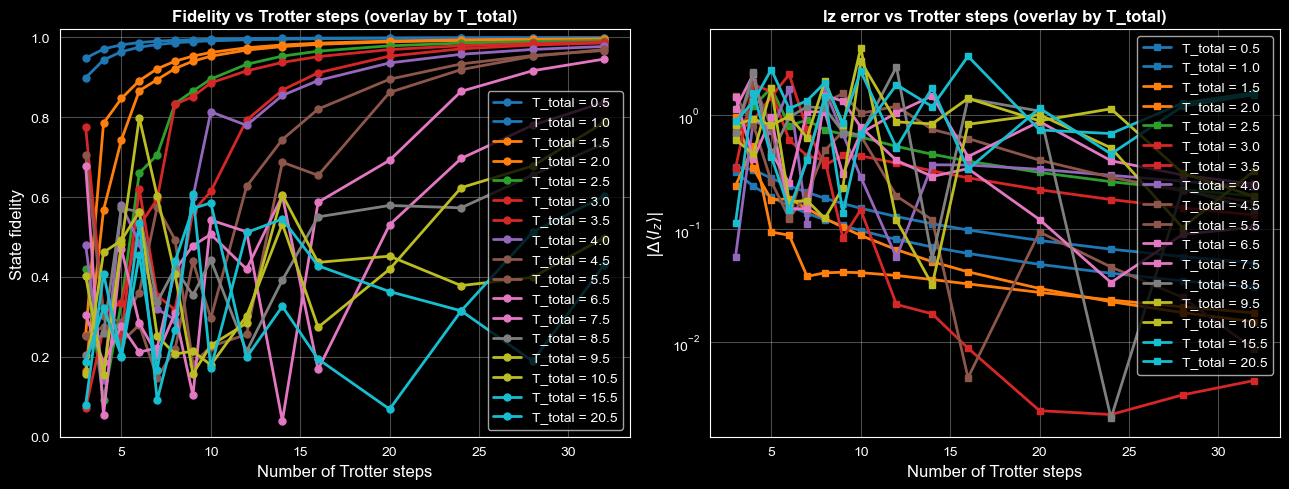


Fidelity range: [0.039089, 0.999557]
Iz error range: [2.147051e-03, 3.895544e+00]


In [21]:
# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = plt.cm.tab10(np.linspace(0, 1, n_T_values))

for t_idx, T_total_val in enumerate(T_total_list):
    label = f'T_total = {T_total_val:.1f}'
    axes[0].plot(
        n_trotter_list, fidelity_matrix[t_idx, :], 'o-',
        linewidth=2, markersize=5, color=colors[t_idx], label=label,
    )
    axes[1].plot(
        n_trotter_list, delta_Iz_matrix[t_idx, :], 's-',
        linewidth=2, markersize=5, color=colors[t_idx], label=label,
    )

axes[0].set_xlabel('Number of Trotter steps', fontsize=12)
axes[0].set_ylabel('State fidelity', fontsize=12)
axes[0].set_title('Fidelity vs Trotter steps (overlay by T_total)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10, loc='best')
axes[0].set_ylim([0, 1.02])

axes[1].set_xlabel('Number of Trotter steps', fontsize=12)
axes[1].set_ylabel(r'$|\Delta\langle I_z\rangle|$', fontsize=12)
axes[1].set_title('Iz error vs Trotter steps (overlay by T_total)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10, loc='best')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print(f"\nFidelity range: [{np.min(fidelity_matrix):.6f}, {np.max(fidelity_matrix):.6f}]")
print(f"Iz error range: [{np.min(delta_Iz_matrix):.6e}, {np.max(delta_Iz_matrix):.6e}]")

# Section 7: OTOC Protocol from Blocher et al. (Phys. Rev. A 106, 042429)

This section follows the measurement protocol introduced in Blocher et al., *Measuring out-of-time-ordered correlation functions without reversing time evolution*, Phys. Rev. A **106**, 042429 (2022) ([arXiv:2003.03980](https://arxiv.org/abs/2003.03980)).


<font size="5">Background: what an OTOC is and why it's hard</font>

The standard out-of-time-ordered correlator is

$$
F(t) = \langle W^\dagger(t)\, V^\dagger(0)\, W(t)\, V(0) \rangle, \qquad \text{(paper Eq. 1)}
$$

with the associated growth signal

$$
C(t) = \langle |[V(0), W(t)]|^2 \rangle. \qquad \text{(paper Eq. 2)}
$$

The Heisenberg operator $W(t) = U^\dagger(t)\, W\, U(t)$ is what makes this *out-of-time-ordered*: the operators appear in the order $W(t)\, V(0)\, W(t)\, V(0)$ rather than the time-ordered $V(0)\, W(t)\, W(t)\, V(0)$. Measuring $F(t)$ naively requires a **Loschmidt echo** — evolve forward, apply $W$, evolve backward — which means reversing the sign of the system Hamiltonian. For most experimental systems (including the Sb donor we care about) this is not available.

<font size="5">The key trick</font>

Blocher et al. observe that if $V$ is chosen to be the projector onto the *initial pure state*, $V(0) = \rho_0 = |\Psi_0\rangle\langle\Psi_0|$, and $W$ is unitary, then $F(t)$ collapses (paper Eq. 6) to

$$
F(t) = |\langle W(t) \rangle|^2 = |\langle \Psi(t)|\, W\, |\Psi(t)\rangle|^2,
$$

where $|\Psi(t)\rangle = U(t)|\Psi_0\rangle$ is the **forward-evolved** state. No backward evolution is needed — just measure $\langle W \rangle$ at time $t$.

For this same choice of $V$, the growth signal reduces to $C(t) = 1 - F(t)$ (paper, sentence below Eq. 2), which is what we track as the OTOC scrambling indicator.


<font size="5">Choosing $V$ and $W$ for a spin system (Section III.C, III.E of the paper)</font>

We take $|\Psi_0\rangle$ to be a **spin-coherent state** in the direction $(\theta, \phi)$,

$$
|\theta, \phi\rangle = R(\theta, \phi)\, |J, J\rangle, \qquad R(\theta, \phi) = e^{-i\phi J_z}\, e^{-i\theta J_y},
$$

so that $V(0) = |\theta, \phi\rangle\langle\theta, \phi|$. The natural choice for $W$ — one that commutes with $V(0)$ at $t = 0$ so that $C(0) = 0$ — is a small rotation about the *same* axis (paper Eqs. 28–30):

$$
W_\varepsilon = e^{-i\,\varepsilon\, \mathbf{n}(\theta,\phi)\cdot\mathbf{J}} = R(\theta, \phi)\, e^{-i\,\varepsilon\, J_z}\, R^\dagger(\theta, \phi).
$$

Because $W_\varepsilon$ is a unitary, its eigenstates are $|\psi_m\rangle = R(\theta, \phi)\,|J, m\rangle$ with eigenvalues $\lambda_m = e^{-i\,\varepsilon\, m}$.

<font size="5">Reconstructing $F(t)$ from a forward-only measurement</font>

Expand $|\Psi(t)\rangle$ in the eigenbasis of $W_\varepsilon$ to get amplitudes $c_m(t) = \langle\psi_m|\Psi(t)\rangle$ and populations $P_m(t) = |c_m(t)|^2$. Then (paper Eq. 7)

$$
\langle W_\varepsilon(t)\rangle = \sum_m P_m(t)\, e^{-i\,\varepsilon\, m}, \qquad F(t) = \big|\langle W_\varepsilon(t)\rangle\big|^2, \qquad C(t) = 1 - F(t).
$$

The experimental procedure (paper, Section III.E):

1. Prepare $|\Psi_0\rangle = R(\theta, \phi)\,|J, J\rangle$ and evolve forward to time $t$, giving $|\Psi(t)\rangle$.
2. Apply $R^\dagger(\theta, \phi)$ to $|\Psi(t)\rangle$ and project onto the $J_z$ eigenbasis — i.e. **measure in the rotated basis** — to sample $P_m(t) = |\langle J, m|\, R^\dagger(\theta, \phi)\, |\Psi(t)\rangle|^2$.
3. Combine the populations with the known phases $\lambda_m = e^{-i\,\varepsilon\, m}$ to get $\langle W_\varepsilon \rangle$, and hence $F(t)$ and $C(t)$.

The role of each parameter:

| Symbol | Meaning |
|---|---|
| $(\theta, \phi)$ | direction of the initial spin-coherent state, **and** axis of the perturbation $W_\varepsilon$. Both share the same axis so that $[V(0), W_\varepsilon] = 0$ at $t = 0$. |
| $\varepsilon$ | rotation angle in $W_\varepsilon = e^{-i\,\varepsilon\, n\cdot J}$. Sets the eigenvalues $\lambda_m$ but leaves the eigenstates alone, so a single trajectory yields the OTOC for a whole family of $\varepsilon$ values. |
| $J$ | total angular momentum (`otoc_spin = 3.5` here — the I = 7/2 antimony nucleus). |

<font size="5">Why $C(t) = 1 - F(t)$ tracks scrambling</font>

At $t = 0$, $R^\dagger(\theta, \phi)\,|\Psi_0\rangle = |J, J\rangle$, so $P_m(0) = \delta_{m, J}$ and $\langle W_\varepsilon\rangle(0) = e^{-i\,\varepsilon J}$, giving $F(0) = 1$ and $C(0) = 0$. As the dynamics spread $|\Psi(t)\rangle$ across the rotated basis, the populations $P_m(t)$ flatten and the phase-weighted sum $\sum_m P_m\, e^{-i\,\varepsilon\, m}$ experiences cancellations, so $F(t)$ drops below 1 and $C(t)$ grows. Chaotic dynamics scramble information across many basis states and produce sustained growth of $C(t)$; regular dynamics keep $|\Psi(t)\rangle$ near a small set of eigenstates and $C(t)$ stays near zero.

<font size="5">Caveat for small spin ($J = 7/2$) and large $\varepsilon$</font>

The paper uses $\varepsilon = \pi/40$ for $J = 41/2$. For our $J = 7/2$ donor the OTOC visibility is small at that $\varepsilon$ — Section IV.A of the paper shows the same effect and resolves it by increasing $\varepsilon$ up to $\pi/4$ (their Fig. 7). We push further to `otoc_eps = π/2` below, which gives a large modulation but moves us out of the perturbative regime where $C(t) \approx \varepsilon^2\, \sigma_{J'}^2(t)$ holds. $C(t)$ is still a valid scrambling indicator for the chaotic Hamiltonian, but it no longer reduces to a clean variance-of-rotated-angular-momentum proxy.

<font size="5">orkflow used in this section</font>

1. Section 7.1 — prepare $|\Psi_0\rangle$, build $V$ and $W_\varepsilon$, and verify $\|[V, W_\varepsilon]\| \approx 0$ at $t = 0$.
2. Section 7.2 — continuous reference trajectory via `Spin.evolve()` plus OTOC reconstruction via `psyduck.evolve.otoc_trajectory` (described in the next cell).
3. Section 7.3 — plot $C(t)$ and the rotated-basis populations.
4. Section 7.4 — replace the continuous propagator with a first-order Trotter step (via `kicked_dynamics()`) and compare $C(t)$ traces.
5. Section 7.5 — sweep the Trotter number $N$ at fixed total time to study convergence.


## Section 7.1: Setup the OTOC protocol


In [22]:
otoc_spin = 3.5
otoc_nucleus = Spin(I=otoc_spin)
otoc_Ix, otoc_Iy, otoc_Iz = otoc_nucleus.get_spin_operators()

otoc_gamma = 2*np.pi*400
otoc_order = 2
otoc_rabi = 2 * np.pi * 1 / (2 * (1888409 / 1e9))

otoc_Hzz = Hz_order(otoc_gamma, otoc_order, otoc_spin)
otoc_Hy = -otoc_rabi * otoc_Iy
otoc_H = otoc_Hy + otoc_Hzz

otoc_theta = np.pi / 2
otoc_phi = 0.0
otoc_eps = np.pi / 2

otoc_nucleus.make_displaced_coherent_state(theta=otoc_theta, phi=otoc_phi)
otoc_psi0 = otoc_nucleus.state.copy()
otoc_rho0 = otoc_psi0 * otoc_psi0.dag()

# Create otoc_V
otoc_V_nucleus = Spin(I=otoc_spin)
otoc_V_nucleus.make_displaced_coherent_state(theta=otoc_theta, phi=otoc_phi)
otoc_V_psi = otoc_V_nucleus.state
otoc_V = otoc_V_psi * otoc_V_psi.dag()

otoc_rotation = global_rotation(otoc_spin, otoc_phi, 'z') * global_rotation(otoc_spin, otoc_theta, 'y')
otoc_W_eps = otoc_rotation * (-1j * otoc_eps * otoc_Iz).expm() * otoc_rotation.dag()  # W_eps written in the lab basis

print("=== Section 7.1 ===")

print(f"Spin(I={otoc_spin}) with dimension {otoc_nucleus.dim}")
print(f"OTOC angles: theta = {otoc_theta:.3f}, phi = {otoc_phi:.3f}")
print(f"epsilon = {otoc_eps:.3f}")
print(f"||[V, W_eps]|| at t = 0 = {qt.commutator(otoc_V, otoc_W_eps).norm():.6e}")
otoc_H

=== Section 7.1 ===
Spin(I=3.5) with dimension 8
OTOC angles: theta = 1.571, phi = 0.000
epsilon = 1.571
||[V, W_eps]|| at t = 0 = 1.018917e-15


Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[4398.22971503   +0.j            0.        +2200.76076794j
     0.           +0.j            0.           +0.j
     0.           +0.j            0.           +0.j
     0.           +0.j            0.           +0.j        ]
 [   0.        -2200.76076794j 2243.99475256   +0.j
     0.        +2881.47223017j    0.           +0.j
     0.           +0.j            0.           +0.j
     0.           +0.j            0.           +0.j        ]
 [   0.           +0.j            0.        -2881.47223017j
   807.83811092   +0.j            0.        +3221.58389097j
     0.           +0.j            0.           +0.j
     0.           +0.j            0.           +0.j        ]
 [   0.           +0.j            0.           +0.j
     0.        -3221.58389097j   89.7597901    +0.j
     0.        +3327.2375355j     0.           +0.j
     0.           +0.j            0.           +0.j        ]
 [   0.      

### Code-to-protocol mapping: how `otoc_trajectory` works

The function `otoc_trajectory(states, theta, phi, eps, j)` lives in `psyduck.evolve` and implements the Blocher protocol end-to-end.

The function does three things, in order.

#### One-time setup — build the basis rotation $R(\theta, \phi)$

```python
rotation = global_rotation(j, phi, 'z') * global_rotation(j, theta, 'y')   # R = Rz(φ)·Ry(θ)
R_dag = rotation.dag()
m_vals = np.arange(j, -j - 1, -1)                                          # [+j, +j-1, ..., -j]
phases = np.exp(-1j * eps * m_vals)                                        # λ_m = exp(-i ε m)
```

$R(\theta, \phi)$ is the rotation that takes $|J, J\rangle$ to the spin-coherent state and simultaneously diagonalizes $W_\varepsilon$ (paper Eqs. 28–31). It depends only on $(\theta, \phi)$, so we build it **once** outside the trajectory loop. Likewise, the phase factors $\lambda_m$ depend only on $\varepsilon$ — they're computed once and reused for every state.

`m_vals = np.arange(j, -j - 1, -1)` orders the magnetic quantum numbers from $+j$ down to $-j$ to match QuTiP's `jmat(j, 'z')` diag convention; index $i$ of `populations` corresponds to $m = j - i$.

#### Per-state step 1 — sample populations $P_m(t)$ in the $W_\varepsilon$ eigenbasis

```python
if state.isket:
    psi_prime = R_dag * state                                # ψ' = R† ψ
    probs = np.abs(psi_prime.full().ravel()) ** 2            # P_m = |ψ'_m|²
else:
    rho_prime = R_dag * state * rotation                     # ρ' = R† ρ R
    probs = np.real_if_close(rho_prime.diag()).real          # P_m = ⟨J,m| ρ' |J,m⟩
```

This is **step 2 of the experimental procedure**: transform into the $W_\varepsilon$ eigenbasis and read out the populations. For a ket (which is what `Spin.evolve()` and `kicked_dynamics()` return), rotating the state vector directly is cheaper than forming the full density matrix.

#### Per-state step 2 — reconstruct $\langle W_\varepsilon\rangle$, $F(t)$, $C(t)$

```python
W_expect = np.sum(probs.astype(complex) * phases)            # ⟨W_ε⟩ = Σ_m P_m λ_m   (paper Eq. 7)
F_value = abs(W_expect) ** 2                                 # F(t)  = |⟨W_ε⟩|²       (paper Eq. 6)
C_value = 1.0 - F_value                                      # C(t)  = 1 - F(t)
```

This is **step 3 of the experimental procedure**: phase-weight the populations, square the magnitude, take the complement.

#### Sanity check at $t = 0$

Section 7.1 printed $\|[V, W_\varepsilon]\| \approx 1.5 \times 10^{-15}$, confirming that $V$ and $W_\varepsilon$ commute initially as required for $C(0) = 0$. The protocol-level check is that at $t = 0$, $R^\dagger |\Psi_0\rangle = |J, J\rangle$ so $P_m(0) = \delta_{m, J}$ and $|\langle W_\varepsilon\rangle(0)|^2 = 1$ — Section 7.2 below confirms this gives `C(0) ≈ 0` numerically.

#### Why the same trajectory works for any $\varepsilon$

The populations $P_m(t)$ depend only on $(\theta, \phi)$, not on $\varepsilon$. Only the phase factors $\lambda_m = e^{-i\,\varepsilon\, m}$ depend on $\varepsilon$. So once a trajectory has been computed, you can post-process $F(t)$ for any $\varepsilon$ by re-weighting the same `populations` array — a single experiment yields the OTOC for a whole family of perturbation strengths.


## 7.2 Continuous evolution and OTOC reconstruction

First compute a continuous reference trajectory with `Spin.evolve()`. Then reconstruct the paper's Loschmidt-echo-style quantity `F(t)` and the growth signal `C(t) = 1 - F(t)` from the populations in the rotated `H'` basis.


In [23]:
# Section 7.2: Continuous OTOC trajectory

otoc_t_max = 3e-3
otoc_t_step = 30e-6
otoc_time = np.arange(0, otoc_t_max + 0.5 * otoc_t_step, otoc_t_step)

otoc_continuous_nucleus = Spin(I=otoc_spin)
otoc_continuous_nucleus.state = otoc_psi0.copy()
otoc_continuous_series = otoc_continuous_nucleus.evolve(otoc_H, otoc_time)

otoc_C_cont, otoc_F_cont, otoc_probs_cont, otoc_m_vals = otoc_trajectory(
    otoc_continuous_series.states,
    theta=otoc_theta,
    phi=otoc_phi,
    eps=otoc_eps,
    j=otoc_spin
)

print("=== Section 7.2 ===")
print(f"Continuous trajectory length: {len(otoc_time)} time points")
print(f"Initial OTOC growth C(0) = {otoc_C_cont[0]:.6f}")
print(f"Final OTOC growth C(t_max) = {otoc_C_cont[-1]:.6f}")


=== Section 7.2 ===
Continuous trajectory length: 101 time points
Initial OTOC growth C(0) = 0.000000
Final OTOC growth C(t_max) = 0.620506


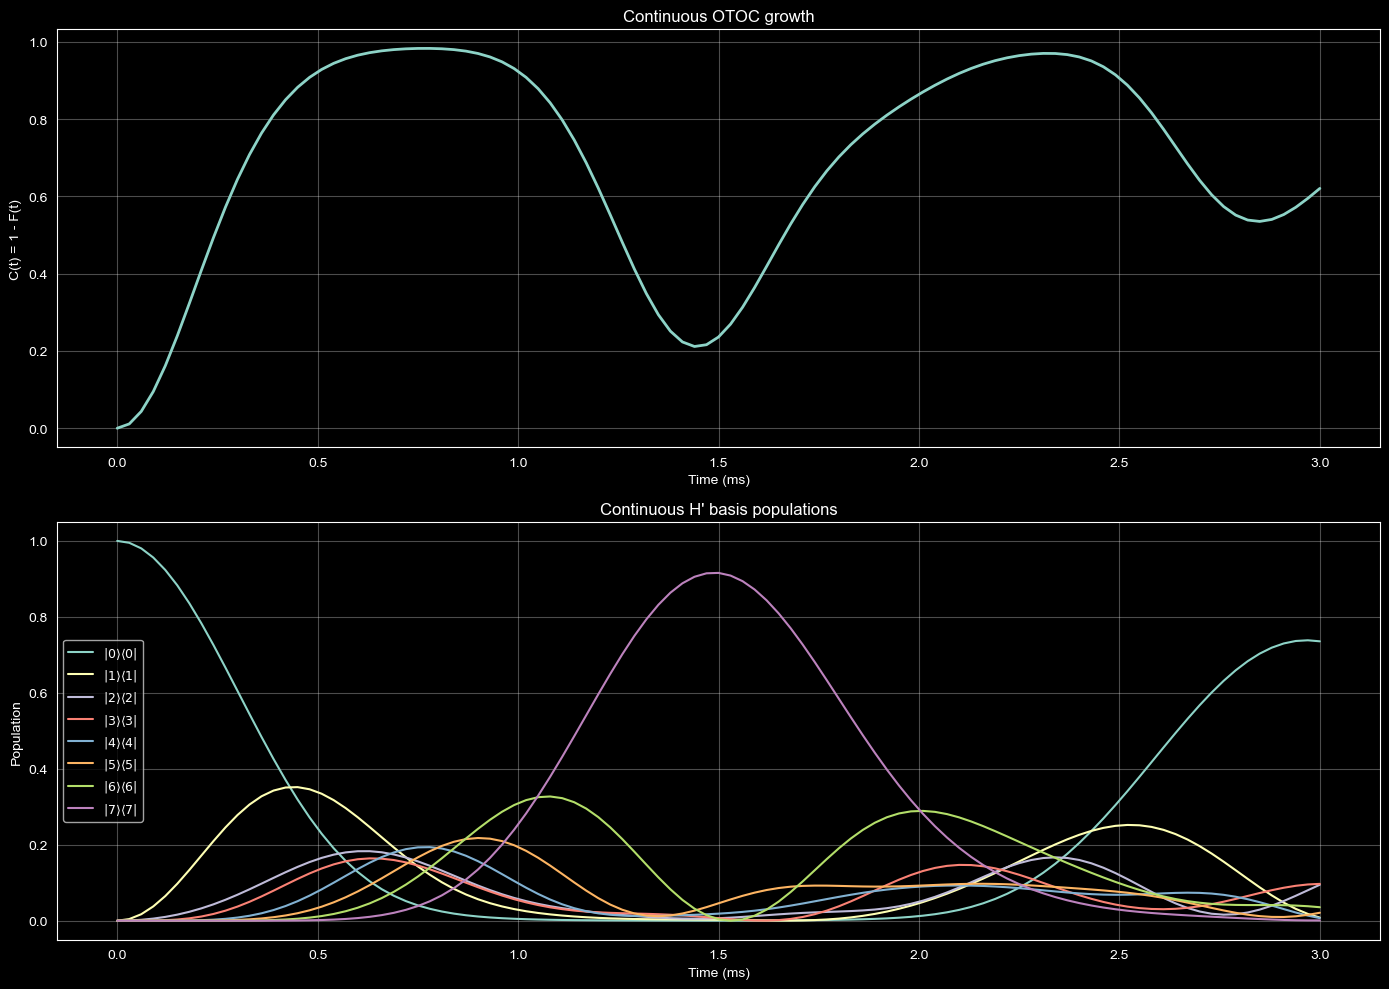

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(otoc_time * 1e3, otoc_C_cont, linewidth=2)
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('C(t) = 1 - F(t)')
axes[0].set_title('Continuous OTOC growth')
axes[0].grid(True, alpha=0.3)

for j in range(otoc_nucleus.dim):
    axes[1].plot(otoc_time * 1e3, otoc_probs_cont[:, j], label=rf'$|{j}\rangle\langle{j}|$')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Population')
axes[1].set_title("Continuous H' basis populations")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

## 7.3 Trotterized evolution and OTOC reconstruction

Same workflow as Section 7.2, but the continuous propagator `Spin.evolve()` is replaced with a first-order Trotter step delivered by `kicked_dynamics()`. The same `otoc_trajectory` post-processing reconstructs `F(t)` and `C(t)` from the rotated-basis populations, so any divergence from the Section 7.2 trace is purely digital approximation error.


In [25]:
# Section 7.3: Trotterized OTOC trajectory

otoc_n_trotter = 6
otoc_delta_t = otoc_time[-1] / otoc_n_trotter
otoc_trotter_time = np.linspace(0, otoc_time[-1], otoc_n_trotter + 1)

# Map Section 7 Trotter step onto kicked_dynamics inputs:
#   Uy_step = exp(i*otoc_rabi*otoc_delta_t*Iy)  ->  tau = 2*otoc_rabi*otoc_delta_t/pi
#   Uz_step = exp(-i*otoc_delta_t*Hz_order(otoc_gamma, otoc_order, otoc_spin))
#                                              ->  kappa = otoc_gamma * otoc_delta_t
otoc_tau_kd = 2 * otoc_rabi * otoc_delta_t / np.pi
otoc_kappa_kd = otoc_gamma * otoc_delta_t

otoc_trotter_nucleus = Spin(I=otoc_spin)
otoc_trotter_nucleus.state = otoc_psi0.copy()

otoc_trotter_states, _, _, _ = kicked_dynamics(
    otoc_psi0,
    tau=otoc_tau_kd,
    kappa=otoc_kappa_kd,
    I=otoc_spin,
    N=otoc_n_trotter,
    order=otoc_order,
    pulse_type='pulse',
)
otoc_C_trotter, otoc_F_trotter, otoc_probs_trotter, _ = otoc_trajectory(
    otoc_trotter_states,
    theta=otoc_theta,
    phi=otoc_phi,
    eps=otoc_eps,
    j=otoc_spin,
)

print("=== Section 7.3 ===")
print(f"Trotter steps: {otoc_n_trotter}")
print(f"delta_t = {otoc_delta_t * 1e6:.2f} us")
print(f"Initial OTOC growth C(0) = {otoc_C_trotter[0]:.6f}")
print(f"Final OTOC growth C(t_max) = {otoc_C_trotter[-1]:.6f}")


=== Section 7.3 ===
Trotter steps: 6
delta_t = 500.00 us
Initial OTOC growth C(0) = -0.000000
Final OTOC growth C(t_max) = 0.865569


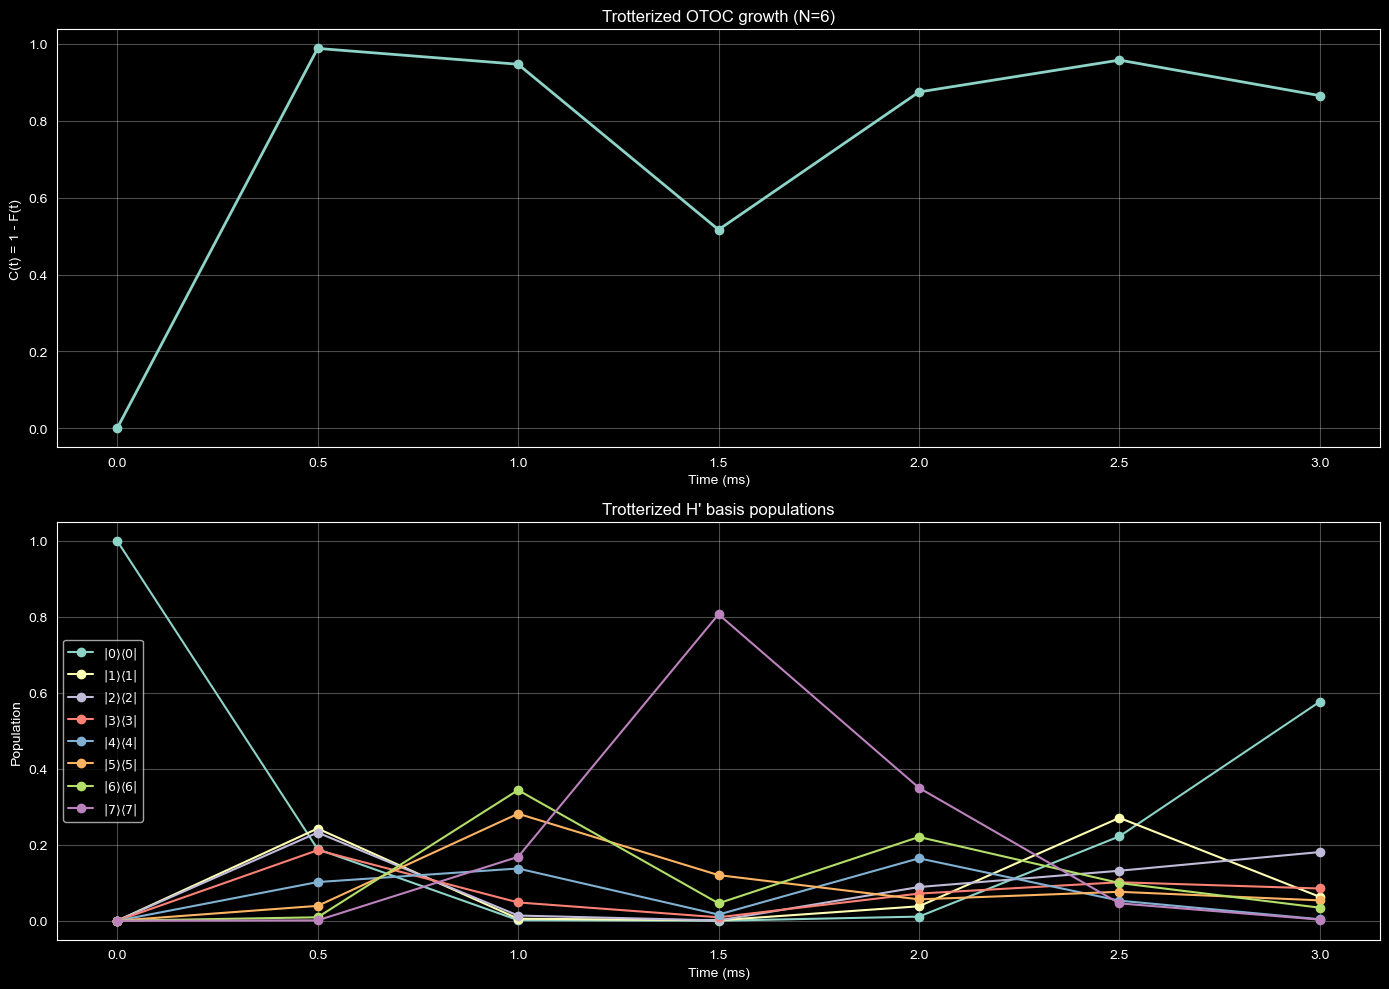

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(otoc_trotter_time * 1e3, otoc_C_trotter, 'o-', linewidth=2)
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('C(t) = 1 - F(t)')
axes[0].set_title(f'Trotterized OTOC growth (N={otoc_n_trotter})')
axes[0].grid(True, alpha=0.3)

for j in range(otoc_nucleus.dim):
    axes[1].plot(otoc_trotter_time * 1e3, otoc_probs_trotter[:, j], 'o-', label=rf'$|{j}\rangle\langle{j}|$')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Population')
axes[1].set_title("Trotterized H' basis populations")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

## 7.4 Compare the continuous and Trotterized OTOC traces

Overlay the Section 7.2 (continuous, `Spin.evolve()`) and Section 7.3 (Trotterized, `kicked_dynamics()`) results on the same axes. Both panels share the same total evolution time; the only difference is the propagator used to advance the state between OTOC samples, so any mismatch isolates the digital approximation error at the level of `C(t)` and `F(t)`.


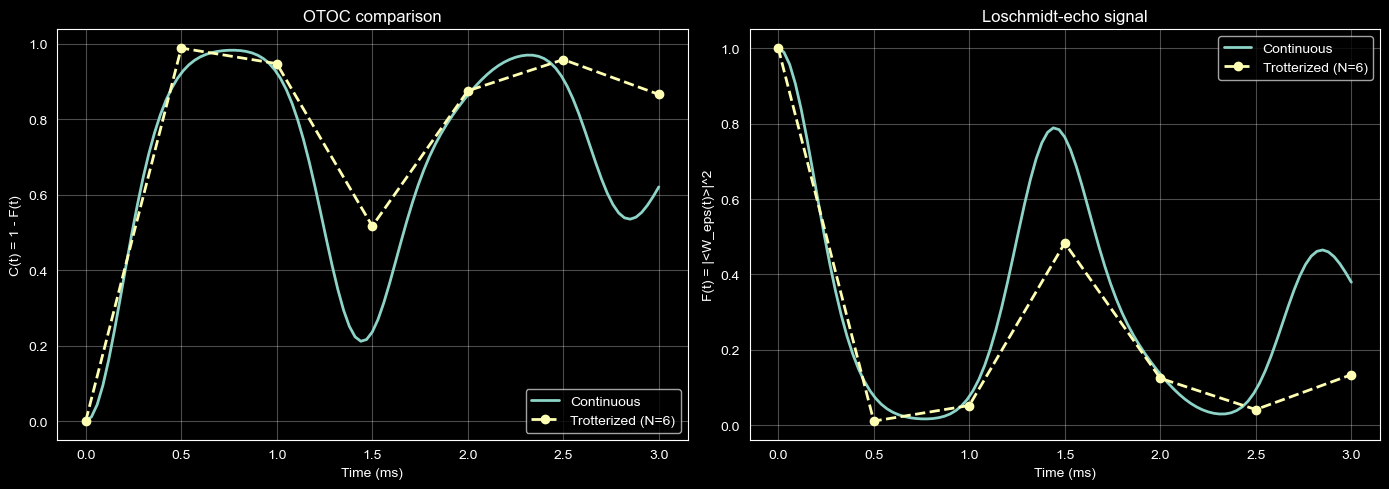

In [27]:
# Section 7.4: Plot continuous and Trotterized OTOC together

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

axes[0].plot(otoc_time * 1e3, otoc_C_cont, linewidth=2, label='Continuous')
axes[0].plot(otoc_trotter_time * 1e3, otoc_C_trotter, 'o--', linewidth=2, label=f'Trotterized (N={otoc_n_trotter})')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('C(t) = 1 - F(t)')
axes[0].set_title('OTOC comparison')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(otoc_time * 1e3, otoc_F_cont, linewidth=2, label='Continuous')
axes[1].plot(otoc_trotter_time * 1e3, otoc_F_trotter, 'o--', linewidth=2, label=f'Trotterized (N={otoc_n_trotter})')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('F(t) = |<W_eps(t)>|^2')
axes[1].set_title('Loschmidt-echo signal')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 7.5 Sweep the Trotter number

This reproduces the last part of the original notebook: fix the total evolution time, vary the Trotter number `N`, and track how both the full OTOC trace and the final-time value converge.


In [34]:
# Section 7.5: Sweep Trotter number at fixed total time

otoc_trotter_numbers = np.arange(1, 21)
otoc_C_traces = {}
otoc_C_final = []

for n_steps in otoc_trotter_numbers:
    dt_local = otoc_time[-1] / n_steps
    tau_local = 2 * otoc_rabi * dt_local / np.pi
    kappa_local = otoc_gamma * dt_local
    trotter_states_local, _, _, _ = kicked_dynamics(
        otoc_psi0,
        tau=tau_local,
        kappa=kappa_local,
        I=otoc_spin,
        N=int(n_steps),
        order=otoc_order,
        pulse_type='pulse',
    )
    C_local, _, _, _ = otoc_trajectory(
        trotter_states_local,
        theta=otoc_theta,
        phi=otoc_phi,
        eps=otoc_eps,
        j=otoc_spin
    )
    otoc_C_traces[int(n_steps)] = C_local
    otoc_C_final.append(C_local[-1])


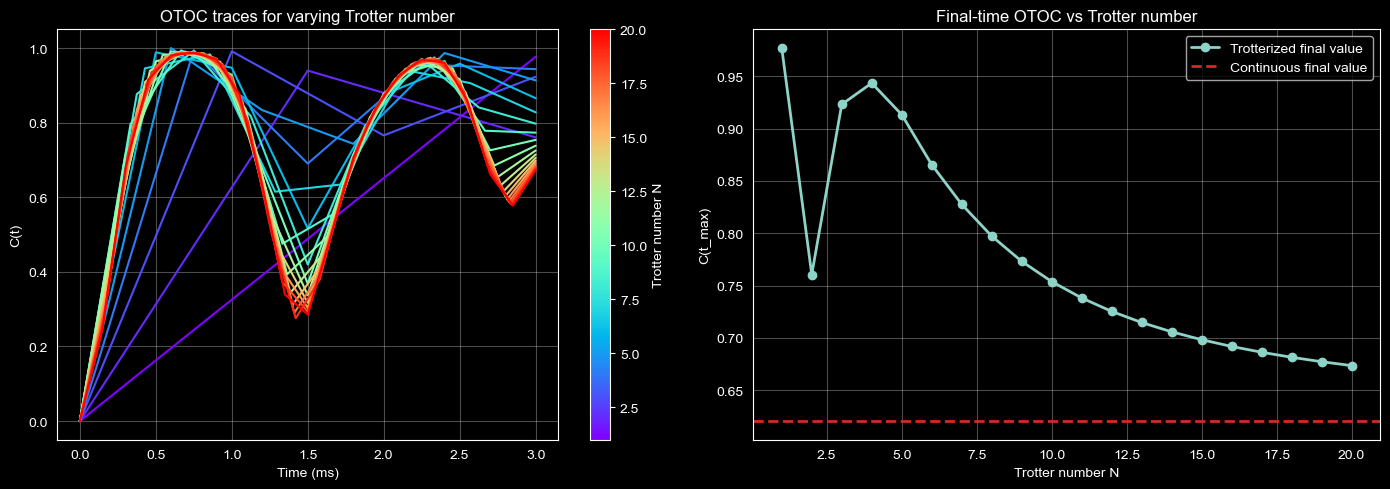

In [35]:
# Section 7.5: Plot the Trotter sweep

from matplotlib.colors import Normalize
from matplotlib import colormaps
from matplotlib.cm import ScalarMappable

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trotter_keys = sorted(otoc_C_traces.keys())
norm = Normalize(vmin=min(trotter_keys), vmax=max(trotter_keys))
cmap = colormaps['rainbow']

for n_steps in trotter_keys:
    C_trace = otoc_C_traces[n_steps]
    t_axis = np.linspace(0, otoc_time[-1] * 1e3, len(C_trace))
    axes[0].plot(t_axis, C_trace, linewidth=1.5, color=cmap(norm(n_steps)))

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=axes[0])
cbar.set_label('Trotter number N')

axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('C(t)')
axes[0].set_title('OTOC traces for varying Trotter number')
axes[0].grid(True, alpha=0.3)

axes[1].plot(otoc_trotter_numbers, otoc_C_final, 'o-', linewidth=2, label='Trotterized final value')
axes[1].axhline(otoc_C_cont[-1], color='tab:red', linestyle='--', linewidth=2, label='Continuous final value')
axes[1].set_xlabel('Trotter number N')
axes[1].set_ylabel('C(t_max)')
axes[1].set_title('Final-time OTOC vs Trotter number')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### Section 7 Notes

The OTOC here is reconstructed from rotated-basis populations rather than from explicit time reversal. In this notebook, the continuous and Trotterized trajectories use the same population-based post-processing, so any mismatch comes from the propagation model rather than from the measurement rule itself.


# Quick Reference

### Available Functions

#### From psyduck:
- `Spin(I=7/2)` - Create spin systems and prepare coherent states
  - `.make_displaced_coherent_state(theta, phi)` - Prepare a spin-coherent state
  - `.get_spin_operators()` - Get `(Ix, Iy, Iz)`
  - `.expectation(operator)` - Calculate expectation values
  - `.evolve(H, times)` - Continuous time evolution under a Hamiltonian (returns `SpinSeries` with `.states` and `.populations()`)
  - `.linear_entropy()` - Calculate linear entropy
  - `.state` - Current quantum state
- `psyduck.evolve.kicked_dynamics()` - Stroboscopic kicked-top simulator (used for both kicked and Trotterized evolution in Sections 4-9)
- `psyduck.evolve.otoc_trajectory(states, theta, phi, eps, j)` - End-to-end OTOC reconstruction following Blocher et al. (Phys. Rev. A 106, 042429). Returns `(C, F, populations, m_vals)`.
- `psyduck.hamiltonians.Hz_order(kappa, order, spin_I)` - Build the higher-order `I_z^order` Hamiltonian
- `psyduck.operations.global_rotation()` - Build full-spin rotation operators
- `psyduck.plotting.wigner_plot_hammer()` - Hammer projection visualization

### Key Points
- Sections 3-7 use `psyduck` for coherent-state preparation, kicked dynamics, and visualization.
- Sections 8-9 trotterize the kicked-top Hamiltonian by reusing `kicked_dynamics()` with a rescaled `tau` and `kappa`:
  - `tau = 2 * omega_y * delta_tau / pi`
  - `kappa = kappa_continuous * delta_tau`
  These two substitutions make `kicked_dynamics()` reproduce a first-order Trotter step `Uz @ Uy` exactly.
- Continuous reference trajectories use `Spin.evolve()` directly.
- All OTOC reconstruction now uses `psyduck.evolve.otoc_trajectory()`.
